<a href="https://colab.research.google.com/github/Chanoknan-P/how-to-select-variables-robustly-in-a-scoring-model/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np     #ใช้สำหรับคำนวณตัวเลขและจัดการข้อมูลจำนวนมาก
import pandas as pd    #ใช้จัดการข้อมูลเป็นตาราง

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/project data mining/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()          #เปิดไฟล์และดูตัวอย่างข้อมูล 5 แถวแรก

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# เรียกดู missing value
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# ดู column
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# กำหนดตัวแปร
continuous_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']
target = "Churn"

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

continuous_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

# จัดการกับ outlier ในตัวแปรต่อเนื่องโดยใช้วิธี IQR
for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # จำกัดค่าผิดปกติไม่ให้สูงหรือต่ำเกินไป โดยไม่ลบทิ้ง
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# แสดงข้อมูลสถิติเชิงพรรณนาอีกครั้งเพื่อดูผลลัพธ์หลังจากจัดการ outlier
df[continuous_vars].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [ ]:
# เปลี่ยนข้อมูลประเภทข้อความให้เป็น ตัวเลข ซึ่งเหมาะกับการนำไปวิเคราะห์หรือสร้าง Machine Learning model และตรวจสอบว่ามีข้อมูลแต่ละกลุ่มจำนวนเท่าไหร่
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


บทความที่ 2 Building Robust Credit Scoring Models with Python

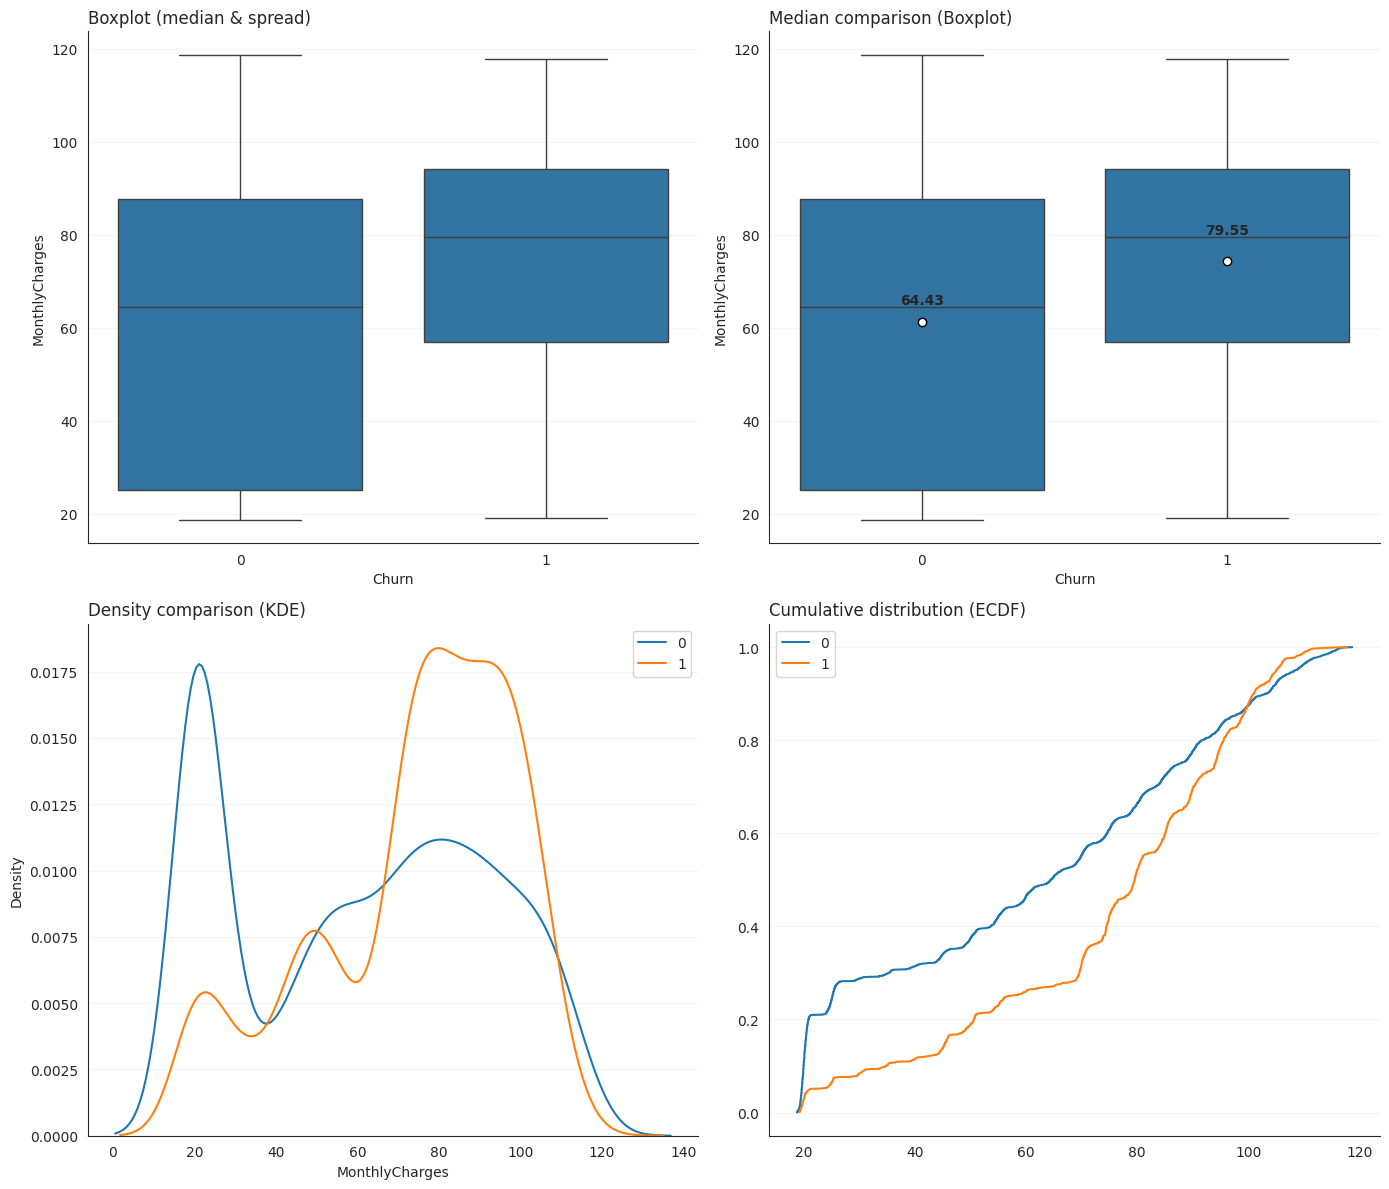

In [ ]:
import seaborn as sns               #สร้างกราฟสำหรับวิเคราะห์ข้อมูลได้ง่ายและดูการกระจายของข้อมูล
import matplotlib.pyplot as plt    #สร้างกราฟจากข้อมูล

# เปรียบเทียบ continuous variable กับ categorical variable
def plot_continuous_vs_categorical(
    df,
    continuous_var,
    categorical_var,
    category_labels=None,
    figsize=(12, 10),
    sample=None
):
    """
     เปรียบเทียบตัวแปรที่เป็นตัวเลข ระหว่างกลุ่มต่าง ๆ โดยใช้ boxplot, KDE, and ECDFแบบ
    และจัดกราฟเป็นช่อง 2×2
    """

    sns.set_style("white")

    data = df[[continuous_var, categorical_var]].dropna().copy()

    # การสุ่มเลือกข้อมูลบางส่วนมาใช้
    if sample:
        data = data.sample(sample, random_state=42)

    categories = sorted(data[categorical_var].unique())

    #  การเปลี่ยนชื่อ labels
    if category_labels:
        labels = [category_labels.get(cat, str(cat)) for cat in categories]
    else:
        labels = [str(cat) for cat in categories]

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1. Boxplot
    sns.boxplot(
        data=data,
        x=categorical_var,
        y=continuous_var,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Boxplot (median & spread)", loc="left")

    # 2. Boxplot สำหรับเปรียบเทียบค่ามัธยฐาน
    sns.boxplot(
        data=data,
        x=categorical_var,
        y=continuous_var,
        ax=axes[0, 1],
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6
        }
    )

    axes[0, 1].set_title("Median comparison (Boxplot)", loc="left")
    medians = data.groupby(categorical_var)[continuous_var].median()

    for i, cat in enumerate(categories):
        axes[0, 1].text(
            i,
            medians[cat],
            f"{medians[cat]:.2f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    # 3. KDE กราฟเส้นโค้งที่แสดงการกระจายของข้อมูล
    for cat, label in zip(categories, labels):
        subset = data[data[categorical_var] == cat][continuous_var]
        sns.kdeplot(
            subset,
            ax=axes[1, 0],
            label=label
        )
    axes[1, 0].set_title("Density comparison (KDE)", loc="left")
    axes[1, 0].legend()

    # 4. ECDF
    for cat, label in zip(categories, labels):
        subset = np.sort(data[data[categorical_var] == cat][continuous_var])
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1, 1].plot(subset, y, label=label)
    axes[1, 1].set_title("Cumulative distribution (ECDF)", loc="left")
    axes[1, 1].legend()

    # ทำเป็นรูปแบบกราฟที่สะอาดและเรียบง่าย
    for ax in axes.flat:
        sns.despine(ax=ax)
        ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_continuous_vs_categorical(
    df=df, # เปลี่ยนจาก train_imputed เป็น df แทน
    continuous_var="MonthlyCharges", # เปลี่ยนจาก person_income
    categorical_var="Churn", # เปลี่ยนจาก def
    category_labels={'No': "No Churn", 'Yes': "Churn"}, # ปรับ lables
    figsize=(14, 12),
    sample=5000
)

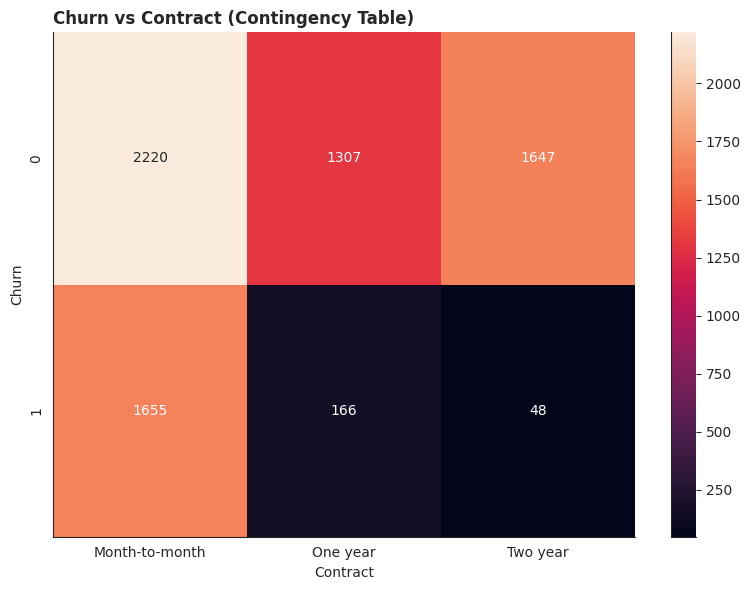

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency  #ใช้ตรวจว่า ตัวแปรประเภทกลุ่ม 2 ตัว มีความสัมพันธ์กันหรือไม่


def contingency_analysis(
    df,
    var1,
    var2,
    normalize=None,   # None, "index", "columns", "all"
    plot=True,
    figsize=(8, 6)
):
    """
    สร้างฟังก์ชันเพื่อทำคำนวณและแสดงตารางความถี่ของข้อมูล 2 ตัวแปร
    Chi-square test + Cramér's V.
    """
    # ตารางไขว้ / ตารางความถี่
    table = pd.crosstab(df[var1], df[var2], margins=False)
    # ตารางที่แปลงจากจำนวนเป็นสัดส่วน/เปอร์เซ็นต์
    if normalize:
        table_norm = pd.crosstab(df[var1], df[var2], normalize=normalize, margins=False).round(3) * 100
    else:
        table_norm = None
    # กราฟ Heatmap
    if plot:
        sns.set_style("white")
        plt.figure(figsize=figsize)
        data_to_plot = table_norm if table_norm is not None else table
        sns.heatmap(
            data_to_plot,
            annot=True,
            fmt=".2f" if normalize else "d",
            cbar=True
        )
        plt.title(f"{var1} vs {var2} (Contingency Table)", loc="left", weight="bold")
        plt.xlabel(var2)
        plt.ylabel(var1)
        sns.despine()
        plt.tight_layout()
        plt.show()

    # ส่ง 'Churn' (หรือ 'def') เป็น var1 และ 'Contract' เป็น var2
contingency_analysis(df, 'Churn', 'Contract')

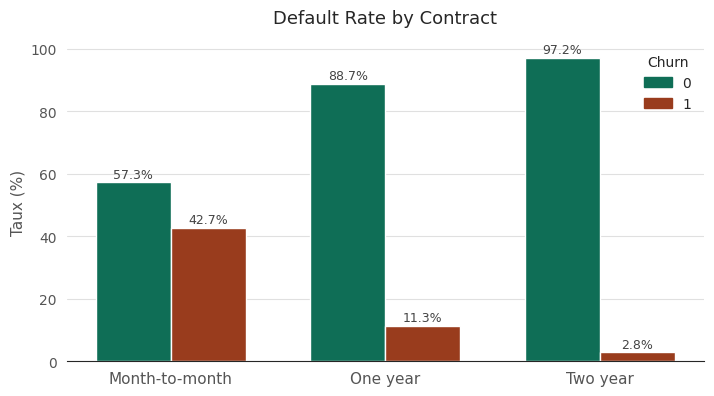

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

def plot_grouped_bar(df, cat_var, subcat_var,
                          normalize="index", title=""):
    ct = pd.crosstab(df[subcat_var], df[cat_var], normalize=normalize) * 100
    modalities = ct.index.tolist()
    categories = ct.columns.tolist()
    n_mod = len(modalities)
    n_cat = len(categories)
    x = np.arange(n_mod)
    width = 0.35

    colors = ['#0F6E56', '#993C1D']  #สีเขียว = ไม่ผิดนัดชำระหนี้, สีน้ำตาล = ผิดนัดชำระหนี้

    fig, ax = plt.subplots(figsize=(7.24, 4.07), dpi=100)

    for i, (cat, color) in enumerate(zip(categories, colors)):
        offset = (i - n_cat / 2 + 0.5) * width
        ax.bar(x + offset, ct[cat], width=width, color=color, label=str(cat))

        # for j, val in enumerate(ct[cat]):
        for j, val in enumerate(ct[cat]):
            ax.text(x[j] + offset, val + 0.5, f"{val:.1f}%",
                    ha='center', va='bottom', fontsize=9, color='#444')

    # การจัดสไตล์ของกราฟ
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_xticks(x)
    ax.set_xticklabels(modalities, fontsize=11)
    ax.set_ylabel("Taux (%)" if normalize else "Effectifs", fontsize=11, color='#555')
    ax.tick_params(left=False, colors='#555')


    handles = [mpatches.Patch(color=c, label=str(l))
               for c, l in zip(colors, categories)]
    ax.legend(handles=handles, title=cat_var, frameon=False,
              fontsize=10, loc='upper right')

    ax.set_title(title, fontsize=13, fontweight='normal', pad=14)
    plt.tight_layout()
    plt.savefig("default_by_ownership.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_grouped_bar(
    df=df,
    cat_var="Churn",
    subcat_var="Contract",
    normalize="index",
    title="Default Rate by Contract"
)

In [ ]:
# ความสัมพันธ์ระหว่างตัวแปรต่อเนื่องกับตัวแปรการผิดนัดชำระหนี้
import pandas as pd
from scipy.stats import kruskal # นำฟังก์ชัน Kruskal-Wallis test เข้ามาใช้งาน

def correlation_quanti_def_KW(database: pd.DataFrame,
                              continuous_vars: list,
                              target: str) -> pd.DataFrame:
    """
    คำนวณค่า p-value จากการทดสอบ Kruskal-Wallis ระหว่างตัวแปรเชิงต่อเนื่องกับตัวแปรเป้าหมายที่เป็นกลุ่ม (มี 2 กลุ่มหรือหลายกลุ่ม)
    ----------
    database : pd.DataFrame
        Input dataset
    continuous_vars : list
        List of continuous variable names
    target : str
        Target variable name (categorical)

    Returns
    -------
    pd.DataFrame
       ตารางที่แสดงตัวแปรแต่ละตัวพร้อมค่า p-value ที่เกี่ยวข้อง
    """

    results = []

    for var in continuous_vars:
        # ลบข้อมูลที่เป็น NA ของตัวแปรที่กำลังวิเคราะห์และตัวแปรเป้าหมายออก
        df_temp = database[[var, target]].dropna() # Renamed df to df_temp to avoid conflict

        #  แบ่งค่าของตัวแปรตามกลุ่มของตัวแปรเป้าหมาย
        groups = [
            group[var].values
            for _, group in df_temp.groupby(target)
        ]

        # Kruskal-Wallis แบ่งค่าของตัวแปรตามกลุ่มของตัวแปรเป้าหมาย
        if len(groups) < 2:
            p_value = None
            stat = None # กำหนดค่าเริ่มต้นให้กับตัวแปร stat สำหรับกรณีนี้
        else:
            try:
                stat, p_value = kruskal(*groups)
            except ValueError:
                # จัดการกรณีที่อาจทำให้โค้ดมีปัญหา เช่น ทำให้ค่าทุกตัวเท่ากัน
                p_value = None
                stat = None # กำหนดค่าเริ่มต้นของ stat สำหรับกรณีนี้

        results.append(
            {
                "variable": var,
                "p_value": p_value,
                "stats_kw": stat
            }
        )

    return pd.DataFrame(results).sort_values(by="p_value")

continuous_vars = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
] # แก้ไข continuous_vars ให้ตรงกับชื่อคอลัมน์ที่มีอยู่จริงใน DataFrame
target = "Churn" # แก้ไขชื่อของตัวแปรเป้าหมายให้ถูกต้อง
result = correlation_quanti_def_KW(
    database=df, # แก้ชื่อ DataFrame จาก database ให้เป็น df
    continuous_vars=continuous_vars,
    target=target
)

print(result)

# บันทึก result เป็นไฟล์ Excel ชื่อ correlations_kw.xlsx ในโฟลเดอร์ correlation

         variable        p_value    stats_kw
0          tenure  2.419140e-208  948.799692
2    TotalCharges   5.684304e-83  372.376884
1  MonthlyCharges   3.311286e-54  240.342632


In [ ]:
# Correlations between qualitative variables and the default variables (Cramer's V)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_with_target(database: pd.DataFrame,
                          categorical_vars: list,
                          target: str) -> pd.DataFrame:
    """
     ความสัมพันธ์ระหว่างตัวแปรเชิงคุณภาพกับตัวแปรเป้าหมายในการผิดนัดชำระหนี้ (โดยใช้ Cramér's V)
    ----------
    database : pd.DataFrame
        Input dataset
    categorical_vars : list
        List of categorical variables
    target : str
        Target variable (categorical)

    Returns
    -------
    pd.DataFrame
        Table with variable, chi2 and Cramér's V
    """

    results = []

    for var in categorical_vars:
        # ลบข้อมูลที่ว่างออก
        df_temp = database[[var, target]].dropna() # เปลี่ยนชื่อ df เป็น df_temp

        #  ตารางแจกแจงความถี่ หรือ ตารางที่เอาตัวแปร 2 ตัวมาเทียบกัน
        contingency_table = pd.crosstab(df_temp[var], df_temp[target])

        # ข้ามขั้นตอนนี้ไป ถ้าข้อมูลมีไม่เพียงพอ
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            results.append({
                "variable": var,
                "chi2": None,
                "cramers_v": None
            })
            continue

        try:
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.values.sum()
            r, k = contingency_table.shape

            v = np.sqrt((chi2 / n) / min(k - 1, r - 1))

        except Exception:
            chi2, v = None, None

        results.append({
            "variable": var,
            "chi2": chi2,
            "cramers_v": v
        })

    result_df = pd.DataFrame(results)

    # เรียงลำดับตามความสำคัญ
    return result_df.sort_values(by="cramers_v", ascending=False)

qualitative_vars = [
   'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
result = cramers_v_with_target(
    database=df, # แก้ไขชื่อข้อมูลจาก database ให้เป็น df
    categorical_vars=qualitative_vars,
    target=target
)

print(result)

# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

            variable         chi2  cramers_v
13          Contract  1184.596572   0.410116
7     OnlineSecurity   849.998968   0.347400
10       TechSupport   828.197068   0.342916
6    InternetService   732.309590   0.322455
15     PaymentMethod   648.142327   0.303359
8       OnlineBackup   601.812790   0.292316
9   DeviceProtection   558.419369   0.281580
12   StreamingMovies   375.661479   0.230951
11       StreamingTV   374.203943   0.230502
14  PaperlessBilling   258.277649   0.191498
3         Dependents   189.129249   0.163870
1      SeniorCitizen   159.426300   0.150453
2            Partner   158.733382   0.150126
5      MultipleLines    11.330441   0.040109
4       PhoneService     0.915033   0.011398
0             gender     0.484083   0.008291


In [ ]:
# Multi-correlations between continuous variables (Spearman test)
import pandas as pd # Ensure pandas is imported

def correlation_matrix_quanti(database: pd.DataFrame,
                              continuous_vars: list,
                              method: str = "spearman",
                              as_percent: bool = False) -> pd.DataFrame:
    """
     คำนวณตารางเมทริกซ์ความสัมพันธ์ของตัวแปรเชิงปริมาณ

    ----------
    database : pd.DataFrame
        Input dataset
    continuous_vars : list
        List of continuous variables
    method : str
        Correlation method ("pearson" or "spearman"), default = "spearman"
    as_percent : bool
        If True, return values in percentage

    Returns
    -------
    pd.DataFrame
        Correlation matrix
    """

    # เลือกเฉพาะข้อมูลที่เกี่ยวข้อง แล้วลบแถวที่มีค่าว่าง (NA) ออก
    df_temp = database[continuous_vars].dropna() # ปลี่ยนชื่อเป็น df_temp เพื่อไม่ให้ชื่อ df ไปทับ df ตัวหลักที่ใช้อยู่

    # ดูว่าตัวแปรตัวเลขแต่ละคู่มีความสัมพันธ์กันมากน้อยแค่ไหน
    corr_matrix = df_temp.corr(method=method)

    # เปลี่ยนค่าเป็นเปอร์เซ็นต์
    if as_percent:
        corr_matrix = corr_matrix * 100

    return corr_matrix

corr = correlation_matrix_quanti(
    database=df, # แก้ไขชื่อ database ให้เป็น df
    continuous_vars=continuous_vars,
    method="spearman"
)

print(corr)

# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.276417      0.889696
MonthlyCharges  0.276417        1.000000      0.638028
TotalCharges    0.889696        0.638028      1.000000


In [ ]:
# Multi-correlations between qualitative variables (Cramer's V)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_matrix(database: pd.DataFrame,
                     categorical_vars: list,
                     corrected: bool = False,
                     as_percent: bool = False) -> pd.DataFrame:
    """
     คำนวณตารางเมทริกซ์ความสัมพันธ์ด้วย Cramér's V สำหรับตัวแปรเชิงกลุ่ม

    ----------
    database : pd.DataFrame
        Input dataset
    categorical_vars : list
        List of categorical variables
    corrected : bool
        Apply bias correction (recommended)
    as_percent : bool
        Return values in percentage

    Returns
    -------
    pd.DataFrame
        Cramér's V matrix
    """

    def cramers_v(x, y):
        # ลบข้อมูลที่เป็นค่าว่าง (NA) ออก
        df_local = pd.DataFrame({"x": x, "y": y}).dropna() # เปลี่ยนชื่อเป็น df_local เพื่อไม่ให้ชื่อ df ไปทับตัวแปร df หลัก

        contingency_table = pd.crosstab(df_local["x"], df_local["y"])

        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            return np.nan

        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.values.sum()
        r, k = contingency_table.shape

        phi2 = chi2 / n

        if corrected:
            # ปรับค่า Cramér's V ให้เหมาะสม
            phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
            r_corr = r - ((r-1)**2) / (n-1)
            k_corr = k - ((k-1)**2) / (n-1)
            denom = min(k_corr - 1, r_corr - 1)
        else:
            denom = min(k - 1, r - 1)

        if denom <= 0:
            return np.nan

        return np.sqrt(phi2_corr / denom) if corrected else np.sqrt(phi2 / denom)

    # กำหนดค่าเริ่มต้นให้ตารางเมทริกซ์
    n = len(categorical_vars)
    matrix = pd.DataFrame(np.zeros((n, n)),
                          index=categorical_vars,
                          columns=categorical_vars)

    # เติมค่าลงในตารางเมทริกซ์
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                value = cramers_v(database[var1], database[var2])
                matrix.loc[var1, var2] = value
                matrix.loc[var2, var1] = value

    # แปลงค่าเป็นเปอร์เซ็นต์
    if as_percent:
        matrix = matrix * 100

    return matrix
matrix = cramers_v_matrix(
    database=df, # แก้ไขชื่อ database ให้เป็น df
    categorical_vars=qualitative_vars,
)

print(matrix)
# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

                    gender  SeniorCitizen   Partner  Dependents  PhoneService  \
gender            0.999716       0.001488  0.001524    0.010207      0.006008   
SeniorCitizen     0.001488       0.999477  0.016093    0.210765      0.007925   
Partner           0.001524       0.016093  0.999716    0.452366      0.017225   
Dependents        0.010207       0.210765  0.452366    0.999662      0.001238   
PhoneService      0.006008       0.007925  0.017225    0.001238      0.999188   
MultipleLines     0.009452       0.146643  0.143898    0.025094      1.000000   
InternetService   0.011320       0.265324  0.000907    0.180267      0.452425   
OnlineSecurity    0.017025       0.211070  0.152010    0.194579      0.176272   
OnlineBackup      0.013798       0.182774  0.153337    0.162760      0.172818   
DeviceProtection  0.006029       0.183071  0.166568    0.157570      0.172317   
TechSupport       0.009722       0.224050  0.127642    0.182377      0.176977   
StreamingTV       0.008844  

บทความที่ 1 How to Select Variables Robustly in a Scoring Model

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
df["fold"] = -1

# แบ่งข้อมูลให้แต่ละกลุ่มด้วยตัวแปรเป้าหมาย (จากต้นฉบับแบ่งข้อมูล ด้วย def + year เพราะมีมิติเวลา)
# ถ้า dataset ไม่มีมิติเวลา ให้แบ่งข้อมูล ด้วยตัวแปรเป้าหมายอย่างเดียวพอ
for fold, (_, test_idx) in enumerate(skf.split(df, df[target])):
    df.loc[test_idx, "fold"] = fold

df["fold"].value_counts()

,count
fold,
1,1761
0,1761
2,1761
3,1760


In [ ]:
def build_folds(df, fold_col="fold", n_splits=4):
    """
    สร้างคู่ (train, test) จากคอลัมน์ fold
    คืนค่าเป็น list of dict: [{"train": df_train, "test": df_test}, ...]
    """
    folds = []
    for f in range(n_splits):
        train_f = df[df[fold_col] != f].copy()
        test_f = df[df[fold_col] == f].copy()
        folds.append({"train": train_f, "test": test_f})
    return folds

folds = build_folds(df, fold_col="fold", n_splits=4) # เปลี่ยน train_imputed เป็น df

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import StratifiedKFold  # หรือใช้ KFold

def build_and_save_folds(df, n_splits=5, target_col="loan_status", fold_col="fold", save_dir="folds/"):
    # 1. สร้างคอลัมน์ fold เปล่าไว้
    df = df.copy()
    df[fold_col] = -1

    # 2. แบ่ง Fold แบบ Stratified (รักษาอัตราส่วน target ให้เท่ากันทุก fold)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(df, df[target_col])):
        df.loc[test_idx, fold_col] = fold

    # 3. สร้างโฟลเดอร์สำหรับบันทึกไฟล์ (ถ้ายังไม่มี)
    os.makedirs(save_dir, exist_ok=True)

    # 4. บันทึกแต่ละ Fold หรือบันทึกไฟล์รวม
    df.to_csv(os.path.join(save_dir, "train_folds.csv"), index=False)
    print(f"บันทึกไฟล์เรียบร้อยที่: {os.path.join(save_dir, 'train_folds.csv')}")

    return df

In [ ]:
folds = build_and_save_folds(df, target_col=target, fold_col="fold", save_dir="folds/")

บันทึกไฟล์เรียบร้อยที่: folds/train_folds.csv


In [ ]:
# เลือก 2 ตัวแปรเชิงหมวดหมู่ให้ตรงตามเรฟ
final_numeric = continuous_vars # กำหนดค่า final_numeric จากผลลัพธ์การคัดเลือกตัวแปรต่อเนื่อง
final_categorical = categorical_vars # อัปเดต final_categorical จากผลลัพธ์ Rule 4 ที่ถูกต้อง
final_features = final_numeric + final_categorical

In [ ]:
folds = build_folds(df, fold_col="fold", n_splits=4)

def kruskal_test_per_var(data, var, target):
    df_ = data[[var, target]].dropna()
    groups = [g[var].values for _, g in df_.groupby(target)]
    if len(groups) < 2:
        return None
    try:
        stat, p = kruskal(*groups)
        return p
    except ValueError:
        return None

def filter_uncorrelated_with_target(folds, variables, target, pvalue_threshold=0.05):
    """
    คัดตัวแปรต่อเนื่องที่มี p-value < threshold (เกณฑ์) ในทุก fold
    """
    kept_vars = []
    detail_rows = []

    for var in variables:
        pvals = []
        for fold in folds:
            p = kruskal_test_per_var(fold["train"], var, target)
            pvals.append(p)
        detail_rows.append({"variable": var, "pvalues_per_fold": pvals})

        # ต้องผ่านทุก fold (p < เกณฑ์) และไม่มี fold ไหนคำนวณไม่ได้
        passed = all((p is not None and p < pvalue_threshold) for p in pvals)
        if passed:
            kept_vars.append(var)

    detail_df = pd.DataFrame(detail_rows)
    return kept_vars, detail_df

rule1_vars, rule1_detail = filter_uncorrelated_with_target(
    folds=folds, variables=continuous_vars, target=target, pvalue_threshold=0.05
)
print("ผ่าน Rule 1:", rule1_vars)
rule1_detail

ผ่าน Rule 1: ['tenure', 'MonthlyCharges', 'TotalCharges']


,variable,pvalues_per_fold
0,tenure,"[1.2375428543579322e-151, 1.3585850574211454e-..."
1,MonthlyCharges,"[1.7235491105580666e-39, 6.623797726898302e-38..."
2,TotalCharges,"[5.628748251347063e-60, 3.645940016444204e-64,..."


In [ ]:
def cramers_v(x, y):
    df_ = pd.DataFrame({"x": x, "y": y}).dropna()
    table = pd.crosstab(df_["x"], df_["y"])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

def filter_categorical_variables(folds, cat_variables, target, low_threshold=0.10, high_threshold=0.50):
    """
    คัดตัวแปร categorical ที่ Cramér's V >= low_threshold ในทุก fold
    (high_threshold (เกณฑ์ค่าสูง) ใช้แค่เป็น reference สำหรับตีความความแรง ไม่ใช้กรอง)
    """
    kept_vars = []
    detail_rows = []

    for var in cat_variables:
        v_values = []
        for fold in folds:
            v = cramers_v(fold["train"][var], fold["train"][target])
            v_values.append(v)
        detail_rows.append({"variable": var, "cramers_v_per_fold": v_values})

        passed = all((v is not None and not np.isnan(v) and v >= low_threshold) for v in v_values)
        if passed:
            kept_vars.append(var)

    detail_df = pd.DataFrame(detail_rows)
    return kept_vars, detail_df

rule2_vars, rule2_detail = filter_categorical_variables(
    folds=folds, cat_variables=categorical_vars, target=target,
    low_threshold=0.13, high_threshold=0.50
)
print("ผ่าน Rule 2:", rule2_vars)
rule2_detail

ผ่าน Rule 2: ['SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,variable,cramers_v_per_fold
0,gender,"[0.012979661291946413, 0.008957444988888546, 0..."
1,SeniorCitizen,"[0.1452775456225114, 0.1532722122558644, 0.151..."
2,Partner,"[0.14322591530070575, 0.14254891503602873, 0.1..."
3,Dependents,"[0.15802575064534416, 0.16027789950381344, 0.1..."
4,PhoneService,"[0.01420868878969879, 0.0, 0.02651425347597662..."
5,MultipleLines,"[0.04124739764172758, 0.02963962916757777, 0.0..."
6,InternetService,"[0.32106919354867725, 0.3194183535671455, 0.33..."
7,OnlineSecurity,"[0.34291928955511064, 0.34470861944405706, 0.3..."
8,OnlineBackup,"[0.2826308061015307, 0.2909495941002683, 0.305..."
9,DeviceProtection,"[0.27463464685914935, 0.2808188007233656, 0.29..."


In [ ]:
def filter_correlated_variables_kfold(folds, variables, target, threshold=0.60):
    """
    ถ้าคู่ตัวแปรมี Spearman correlation >= threshold (เกณฑ์) ใน fold ใดก็ตาม
    ให้ตัดตัวที่สัมพันธ์กับตัวแปรเป้าหมายอ่อนกว่า (ดูจาก Kruskal-Wallis p-value เฉลี่ยทุก fold)
    """
    variables = list(variables)
    to_drop = set()

    # เตรียม p-value เฉลี่ยของแต่ละตัวแปรกับ target (ยิ่งน้อยยิ่งสัมพันธ์แรง)
    avg_pvalues = {}
    for var in variables:
        pvals = [kruskal_test_per_var(f["train"], var, target) for f in folds]
        pvals = [p for p in pvals if p is not None]
        avg_pvalues[var] = np.mean(pvals) if pvals else np.inf

    # เช็คทุก fold ทุกคู่ตัวแปร
    for fold in folds:
        corr = fold["train"][variables].corr(method="spearman").abs()
        for i in range(len(variables)):
            for j in range(i + 1, len(variables)):
                v1, v2 = variables[i], variables[j]
                if v1 in to_drop or v2 in to_drop:
                    continue
                if corr.loc[v1, v2] >= threshold:
                    # ตัดตัวที่ p-value เฉลี่ยแย่กว่า (มากกว่า) ทิ้ง
                    drop_var = v1 if avg_pvalues[v1] > avg_pvalues[v2] else v2
                    to_drop.add(drop_var)

    selected = [v for v in variables if v not in to_drop]
    return selected, sorted(to_drop)

selected_continuous, dropped_continuous = filter_correlated_variables_kfold(
    folds=folds, variables=rule1_vars, target=target, threshold=0.60
)
print("ตัวแปรต่อเนื่องที่เหลือ:", selected_continuous)
print("ตัดทิ้ง (ซ้ำซ้อน):", dropped_continuous)

ตัวแปรต่อเนื่องที่เหลือ: ['tenure', 'MonthlyCharges']
ตัดทิ้ง (ซ้ำซ้อน): ['TotalCharges']


In [ ]:
def filter_correlated_categorical_variables(folds, cat_variables, target, high_threshold=0.50):
    """
    ถ้าคู่ตัวแปร categorical มี Cramér's V >= high_threshold (เกณฑ์ค่าสูง) ใน fold ใดก็ตาม
    ให้ตัดตัวที่สัมพันธ์กับตัวแปรเป้าหมายอ่อนกว่า
    """
    cat_variables = list(cat_variables)
    to_drop = set()

    avg_v_with_target = {}
    for var in cat_variables:
        v_values = [cramers_v(f["train"][var], f["train"][target]) for f in folds]
        v_values = [v for v in v_values if v is not None and not np.isnan(v)]
        avg_v_with_target[var] = np.mean(v_values) if v_values else 0

    for fold in folds:
        for i in range(len(cat_variables)):
            for j in range(i + 1, len(cat_variables)):
                v1, v2 = cat_variables[i], cat_variables[j]
                if v1 in to_drop or v2 in to_drop:
                    continue
                v_pair = cramers_v(fold["train"][v1], fold["train"][v2])
                if v_pair is not None and not np.isnan(v_pair) and v_pair >= high_threshold:
                    # ตัดตัวที่สัมพันธ์กับ target อ่อนกว่า (avg cramers_v น้อยกว่า)
                    drop_var = v1 if avg_v_with_target[v1] < avg_v_with_target[v2] else v2
                    to_drop.add(drop_var)

    selected = [v for v in cat_variables if v not in to_drop]
    return selected, sorted(to_drop)

selected_categorical, dropped_categorical = filter_correlated_categorical_variables(
    folds=folds, cat_variables=rule2_vars, target=target, high_threshold=0.50
)
print("ตัวแปร categorical ที่เหลือ:", selected_categorical)
print("ตัดทิ้ง (ซ้ำซ้อน):", dropped_categorical)

ตัวแปร categorical ที่เหลือ: ['SeniorCitizen', 'Partner', 'Dependents', 'OnlineSecurity', 'Contract', 'PaperlessBilling', 'PaymentMethod']
ตัดทิ้ง (ซ้ำซ้อน): ['DeviceProtection', 'InternetService', 'OnlineBackup', 'StreamingMovies', 'StreamingTV', 'TechSupport']


In [ ]:
final_variables = selected_continuous + selected_categorical

print("=" * 50)
print(f"เริ่มต้น: {len(continuous_vars)} ตัวแปรต่อเนื่อง + {len(categorical_vars)} ตัวแปร categorical")
print(f"ผ่าน Rule 1 (Kruskal-Wallis, ทุก fold): {len(rule1_vars)} ตัว")
print(f"ผ่าน Rule 2 (Cramér's V vs target, ทุก fold): {len(rule2_vars)} ตัว")
print(f"หลัง Rule 3 (ตัด multicollinearity ต่อเนื่อง): {len(selected_continuous)} ตัว")
print(f"หลัง Rule 4 (ตัด multicollinearity categorical): {len(selected_categorical)} ตัว")
print("=" * 50)
print(f"ตัวแปรสุดท้าย ({len(final_variables)} ตัว):")
print(final_variables)

เริ่มต้น: 3 ตัวแปรต่อเนื่อง + 16 ตัวแปร categorical
ผ่าน Rule 1 (Kruskal-Wallis, ทุก fold): 3 ตัว
ผ่าน Rule 2 (Cramér's V vs target, ทุก fold): 13 ตัว
หลัง Rule 3 (ตัด multicollinearity ต่อเนื่อง): 2 ตัว
หลัง Rule 4 (ตัด multicollinearity categorical): 7 ตัว
ตัวแปรสุดท้าย (9 ตัว):
['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Partner', 'Dependents', 'OnlineSecurity', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# สร้าง Dataframe สรุป Pipeline ตามเงื่อนไข Rule 1 - Rule 4
pipeline_summary = pd.DataFrame({
    "Filtering Stage": [
        "1. Numerical Selection (Kruskal-Wallis, all folds)",
        "2. Categorical Selection (Cramér's V vs Target, all folds)",
        "3. Numerical Multicollinearity (Spearman >= 0.60, any fold)",
        "4. Categorical Multicollinearity (Cramér's V >= 0.50, any fold)",
    ],
    "Input Count": [len(continuous_vars), len(categorical_vars), len(rule1_vars), len(rule2_vars)],
    "Dropped Variable": [
        sorted(set(continuous_vars) - set(rule1_vars)) or "None",
        sorted(set(categorical_vars) - set(rule2_vars)) or "None",
        dropped_continuous if dropped_continuous else "None",
        dropped_categorical if dropped_categorical else "None",
    ],
    "Remaining Count": [len(rule1_vars), len(rule2_vars), len(selected_continuous), len(selected_categorical)],
})

final_variables = selected_continuous + selected_categorical
selected_features = final_variables + [target]
final_df = df[selected_features].copy()

display(pipeline_summary)

# บันทึกเป็น CSV สำหรับก๊อปปี้ไปแปะใน Excel / Google Slides
pipeline_summary.to_csv("feature_selection_summary.csv", index=False, encoding='utf-8-sig')

# แสดงผลตาราง
display(pipeline_summary)

,Filtering Stage,Input Count,Dropped Variable,Remaining Count
0,"1. Numerical Selection (Kruskal-Wallis, all fo...",3,None,3
1,2. Categorical Selection (Cramér's V vs Target...,16,"[MultipleLines, PhoneService, gender]",13
2,3. Numerical Multicollinearity (Spearman >= 0....,3,[TotalCharges],2
3,4. Categorical Multicollinearity (Cramér's V >...,13,"[DeviceProtection, InternetService, OnlineBack...",7


,Filtering Stage,Input Count,Dropped Variable,Remaining Count
0,"1. Numerical Selection (Kruskal-Wallis, all fo...",3,None,3
1,2. Categorical Selection (Cramér's V vs Target...,16,"[MultipleLines, PhoneService, gender]",13
2,3. Numerical Multicollinearity (Spearman >= 0....,3,[TotalCharges],2
3,4. Categorical Multicollinearity (Cramér's V >...,13,"[DeviceProtection, InternetService, OnlineBack...",7


In [ ]:
selected_features = [
    'tenure',
    'MonthlyCharges',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'OnlineSecurity',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

final_df = df[selected_features].copy()

destination_path = '/content/drive/MyDrive/project data mining/churn/selected_features_Telco Customer Churn.csv'

# แยกที่อยู่ของโฟลเดอร์ออกมาจาก destination_path
directory = os.path.dirname(destination_path)

# สร้างโฟลเดอร์
os.makedirs(directory, exist_ok=True)

final_df.to_csv(destination_path, index=False, encoding='utf-8-sig')

print(f"บันทึกไฟล์ลง Google Drive เรียบร้อยแล้วที่: {destination_path}")

บันทึกไฟล์ลง Google Drive เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/churn/selected_features_Telco Customer Churn.csv


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal, chi2_contingency

# กำหนดฟังก์ชันสำหรับคำนวณความสัมพันธ์ใหม่อีกครั้ง

def correlation_quanti_def_KW(database: pd.DataFrame,
                              continuous_vars: list,
                              target: str) -> pd.DataFrame:
    results = []
    for var in continuous_vars:
        df_temp = database[[var, target]].dropna()
        groups = [
            group[var].values
            for _, group in df_temp.groupby(target)
        ]
        if len(groups) < 2:
            p_value = None
            stat = None
        else:
            try:
                stat, p_value = kruskal(*groups)
            except ValueError:
                p_value = None
                stat = None
        results.append(
            {
                "variable": var,
                "p_value": p_value,
                "stats_kw": stat
            }
        )
    return pd.DataFrame(results).sort_values(by="p_value")

def cramers_v_with_target(database: pd.DataFrame,
                          categorical_vars: list,
                          target: str) -> pd.DataFrame:
    results = []
    for var in categorical_vars:
        df_temp = database[[var, target]].dropna()
        contingency_table = pd.crosstab(df_temp[var], df_temp[target])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            results.append({"variable": var, "chi2": None, "cramers_v": None})
            continue
        try:
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.values.sum()
            r, k = contingency_table.shape
            v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
        except Exception:
            chi2, v = None, None
        results.append({"variable": var, "chi2": chi2, "cramers_v": v})
    return pd.DataFrame(results).sort_values(by="cramers_v", ascending=False)

def correlation_matrix_quanti(database: pd.DataFrame,
                              continuous_vars: list,
                              method: str = "spearman",
                              as_percent: bool = False) -> pd.DataFrame:
    df_temp = database[continuous_vars].dropna()
    corr_matrix = df_temp.corr(method=method)
    if as_percent:
        corr_matrix = corr_matrix * 100
    return corr_matrix

def cramers_v_matrix(database: pd.DataFrame,
                     categorical_vars: list,
                     corrected: bool = False,
                     as_percent: bool = False) -> pd.DataFrame:
    def cramers_v_calc(x, y):
        df_local = pd.DataFrame({"x": x, "y": y}).dropna()
        contingency_table = pd.crosstab(df_local["x"], df_local["y"])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            return np.nan
        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.values.sum()
        r, k = contingency_table.shape
        phi2 = chi2 / n
        if corrected:
            phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
            r_corr = r - ((r-1)**2) / (n-1)
            k_corr = k - ((k-1)**2) / (n-1)
            denom = min(k_corr - 1, r_corr - 1)
        else:
            denom = min(k - 1, r - 1)
        if denom <= 0:
            return np.nan
        return np.sqrt(phi2_corr / denom) if corrected else np.sqrt(phi2 / denom)

    n = len(categorical_vars)
    matrix = pd.DataFrame(np.zeros((n, n)), index=categorical_vars, columns=categorical_vars)
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                value = cramers_v_calc(database[var1], database[var2])
                matrix.loc[var1, var2] = value
                matrix.loc[var2, var1] = value
    if as_percent:
        matrix = matrix * 100
    return matrix

# คำนวณค่าความสัมพันธ์ใหม่

# ตรวจสอบว่า continuous_vars, categorical_vars, target และ df มีอยู่แล้ว

kruskal_result_df = correlation_quanti_def_KW(
    database=df,
    continuous_vars=continuous_vars,
    target=target
)

cramers_v_target_df = cramers_v_with_target(
    database=df,
    categorical_vars=categorical_vars,
    target=target
)

spearman_corr_matrix = correlation_matrix_quanti(
    database=df,
    continuous_vars=continuous_vars,
    method="spearman",
    as_percent=True # แปลงค่าผลลัพธ์เป็นเปอร์เซ็นต์
)

cramers_v_matrix_df = cramers_v_matrix(
    database=df,
    categorical_vars=categorical_vars,
    as_percent=True # แปลงค่าผลลัพธ์เป็นเปอร์เซ็นต์
)

# บันทึกไฟล์

base_save_path = '/content/drive/MyDrive/project data mining/churn'
os.makedirs(base_save_path, exist_ok=True)

kruskal_result_df.to_csv(os.path.join(base_save_path, 'kruskal_wallis_results.csv'), index=False, encoding='utf-8-sig')
cramers_v_target_df.to_csv(os.path.join(base_save_path, 'cramers_v_target_results.csv'), index=False, encoding='utf-8-sig')
spearman_corr_matrix.to_csv(os.path.join(base_save_path, 'spearman_correlation_matrix_percent.csv'), index=True, encoding='utf-8-sig') # Keep index for matrix, changed filename
cramers_v_matrix_df.to_csv(os.path.join(base_save_path, 'cramers_v_matrix_percent.csv'), index=True, encoding='utf-8-sig') # Keep index for matrix, changed filename

print(f"บันทึกไฟล์ Kruskal-Wallis Results เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'kruskal_wallis_results.csv')}")
print(f"บันทึกไฟล์ Cramér's V vs Target Results เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_target_results.csv')}")
print(f"บันทึกไฟล์ Spearman Correlation Matrix (เป็นเปอร์เซ็นต์) เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'spearman_correlation_matrix_percent.csv')}")
print(f"บันทึกไฟล์ Cramér's V Matrix (เป็นเปอร์เซ็นต์) เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_matrix_percent.csv')}")


บันทึกไฟล์ Kruskal-Wallis Results เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/churn/kruskal_wallis_results.csv
บันทึกไฟล์ Cramér's V vs Target Results เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/churn/cramers_v_target_results.csv
บันทึกไฟล์ Spearman Correlation Matrix (เป็นเปอร์เซ็นต์) เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/churn/spearman_correlation_matrix_percent.csv
บันทึกไฟล์ Cramér's V Matrix (เป็นเปอร์เซ็นต์) เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/churn/cramers_v_matrix_percent.csv


In [ ]:
import os

# ตรวจสอบให้แน่ใจว่า base_save_path ถูกกำหนดไว้แล้ว
# ถ้ายังไม่ได้กำหนด ให้เอาเครื่องหมายคอมเมนต์ออก แล้วกำหนดค่าให้มัน
# base_save_path = '/content/drive/MyDrive/project data mining/ref'
os.makedirs(base_save_path, exist_ok=True)

# บันทึก DataFrame ที่ชื่อ pipeline_summary
pipeline_summary_path = os.path.join(base_save_path, 'pipeline_summary.csv')
pipeline_summary.to_csv(pipeline_summary_path, index=False, encoding='utf-8-sig')

print(f"บันทึกไฟล์ Pipeline Summary เรียบร้อยแล้วที่: {pipeline_summary_path}")

บันทึกไฟล์ Pipeline Summary เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/churn/pipeline_summary.csv
